In [136]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta
import pprint
import pyspark
import pyspark.sql.functions as F

from pyspark.sql.functions import col
from pyspark.sql.types import StringType, IntegerType, FloatType, DateType

import utils.data_processing_bronze_table
import utils.data_processing_silver_table
import utils.data_processing_gold_table

## Set up PySpark Session

In [137]:
# Initialize SparkSession
spark = pyspark.sql.SparkSession.builder \
    .appName("dev") \
    .master("local[*]") \
    .getOrCreate()

# Set log level to ERROR to hide warnings
spark.sparkContext.setLogLevel("ERROR")

## Directories

In [138]:
bronze_lms_directory = "datamart/bronze/lms/"
bronze_fin_directory = "datamart/bronze/financial/"
bronze_attr_directory = "datamart/bronze/attributes/"
bronze_click_directory = "datamart/bronze/clickstream/"

## Build Silver Table for Lms

In [139]:
# create silver datalake for lms_loan
silver_loan_daily_directory = "datamart/silver/lms_loan_daily/"

if not os.path.exists(silver_loan_daily_directory):
    os.makedirs(silver_loan_daily_directory)

In [140]:
# Load all bronze LMS CSVs at once and process
all_lms_files = glob.glob(os.path.join(bronze_lms_directory, '*.csv'))
df = spark.read.csv(all_lms_files, header=True, inferSchema=True)
print(f"loaded {len(all_lms_files)} files, total row count: {df.count()}")

column_type_map = {
    "loan_id": StringType(),
    "Customer_ID": StringType(),
    "loan_start_date": DateType(),
    "tenure": IntegerType(),
    "installment_num": IntegerType(),
    "loan_amt": FloatType(),
    "due_amt": FloatType(),
    "paid_amt": FloatType(),
    "overdue_amt": FloatType(),
    "balance": FloatType(),
    "snapshot_date": DateType(),
}
for column, new_type in column_type_map.items():
    df = df.withColumn(column, col(column).cast(new_type))

df = df.withColumn("mob", col("installment_num").cast(IntegerType()))
df = df.withColumn("installments_missed", F.ceil(col("overdue_amt") / col("due_amt")).cast(IntegerType())).fillna(0)
df = df.withColumn("first_missed_date", F.when(col("installments_missed") > 0, F.add_months(col("snapshot_date"), -1 * col("installments_missed"))).cast(DateType()))
df = df.withColumn("dpd", F.when(col("overdue_amt") > 0.0, F.datediff(col("snapshot_date"), col("first_missed_date"))).otherwise(0).cast(IntegerType()))

lms_silver_path = silver_loan_daily_directory + "silver_loan_daily.parquet"
df.write.mode("overwrite").parquet(lms_silver_path)
print(f"saved to: {lms_silver_path} ({df.count()} rows)")

loaded 24 files, total row count: 104288


saved to: datamart/silver/lms_loan_daily/silver_loan_daily.parquet (104288 rows)


In [141]:
df.toPandas()

,loan_id,Customer_ID,loan_start_date,tenure,installment_num,loan_amt,due_amt,paid_amt,overdue_amt,balance,snapshot_date,mob,installments_missed,first_missed_date,dpd
0,CUS_0x100b_2024_03_01,CUS_0x100b,2024-03-01,10,6,10000.0,1000.0,1000.0,0.0,4000.0,2024-09-01,6,0,None,0
1,CUS_0x1011_2023_11_01,CUS_0x1011,2023-11-01,10,10,10000.0,1000.0,1000.0,0.0,0.0,2024-09-01,10,0,None,0
2,CUS_0x1013_2023_12_01,CUS_0x1013,2023-12-01,10,9,10000.0,1000.0,1000.0,0.0,1000.0,2024-09-01,9,0,None,0
3,CUS_0x1018_2023_11_01,CUS_0x1018,2023-11-01,10,10,10000.0,1000.0,0.0,7000.0,7000.0,2024-09-01,10,7,2024-02-01,213
4,CUS_0x102d_2024_01_01,CUS_0x102d,2024-01-01,10,8,10000.0,1000.0,1000.0,0.0,2000.0,2024-09-01,8,0,None,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104283,CUS_0xe98_2023_01_01,CUS_0xe98,2023-01-01,10,0,10000.0,0.0,0.0,0.0,10000.0,2023-01-01,0,0,None,0
104284,CUS_0xea6_2023_01_01,CUS_0xea6,2023-01-01,10,0,10000.0,0.0,0.0,0.0,10000.0,2023-01-01,0,0,None,0
104285,CUS_0xed3_2023_01_01,CUS_0xed3,2023-01-01,10,0,10000.0,0.0,0.0,0.0,10000.0,2023-01-01,0,0,None,0
104286,CUS_0xed8_2023_01_01,CUS_0xed8,2023-01-01,10,0,10000.0,0.0,0.0,0.0,10000.0,2023-01-01,0,0,None,0


## EDA on Credit Labels

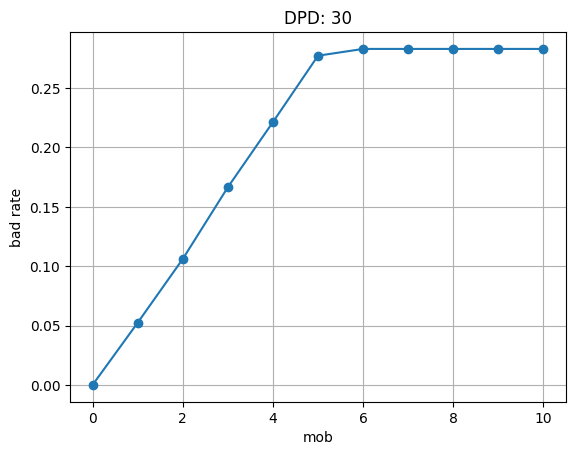

In [142]:
# set dpd label definition
dpd = 30

df = spark.read.parquet(lms_silver_path)

# filter only completed loans
df = df.filter(col("loan_start_date") < datetime.strptime("2024-01-01", "%Y-%m-%d"))

# create dpd flag if more than dpd
df = df.withColumn("dpd_flag", F.when(col("dpd") >= dpd, 1).otherwise(0))

# actual bads 
actual_bads_df = df.filter(col("installment_num") == 10)

# visualise bad rate
pdf = df.toPandas()

# Group by col_A and count occurrences in col_B
grouped = pdf.groupby('mob')['dpd_flag'].mean()

# Sort the index (x-axis) of the grouped DataFrame
grouped = grouped.sort_index()

# Plotting
grouped.plot(kind='line', marker='o')

plt.title('DPD: '+ str(dpd))
plt.xlabel('mob')
plt.ylabel('bad rate')
plt.grid(True)
plt.show()

In [143]:
df.show()

+--------------------+-----------+---------------+------+---------------+--------+-------+--------+-----------+-------+-------------+---+-------------------+-----------------+---+--------+
|             loan_id|Customer_ID|loan_start_date|tenure|installment_num|loan_amt|due_amt|paid_amt|overdue_amt|balance|snapshot_date|mob|installments_missed|first_missed_date|dpd|dpd_flag|
+--------------------+-----------+---------------+------+---------------+--------+-------+--------+-----------+-------+-------------+---+-------------------+-----------------+---+--------+
|CUS_0x1011_2023_1...| CUS_0x1011|     2023-11-01|    10|             10| 10000.0| 1000.0|  1000.0|        0.0|    0.0|   2024-09-01| 10|                  0|             NULL|  0|       0|
|CUS_0x1013_2023_1...| CUS_0x1013|     2023-12-01|    10|              9| 10000.0| 1000.0|  1000.0|        0.0| 1000.0|   2024-09-01|  9|                  0|             NULL|  0|       0|
|CUS_0x1018_2023_1...| CUS_0x1018|     2023-11-01|    1

## Build Silver Table for Financial

In [144]:
# create silver datalake for financial
silver_fin_directory = "datamart/silver/financial/"

if not os.path.exists(silver_fin_directory):
    os.makedirs(silver_fin_directory)

In [145]:
# Load all bronze financial CSVs at once and process
all_fin_files = glob.glob(os.path.join(bronze_fin_directory, '*.csv'))
df = spark.read.csv(all_fin_files, header=True, inferSchema=True)
print(f"loaded {len(all_fin_files)} files, total row count: {df.count()}")

column_type_map = {
    "Customer_ID": StringType(),
    "Annual_Income": FloatType(),
    "Monthly_Inhand_Salary": FloatType(),
    "Num_Bank_Accounts": IntegerType(),
    "Num_Credit_Card": IntegerType(),
    "Interest_Rate": IntegerType(),
    "Num_of_Loan": IntegerType(),
    "Type_of_Loan": StringType(),
    "Delay_from_due_date": IntegerType(),
    "Num_of_Delayed_Payment": IntegerType(),
    "Changed_Credit_Limit": FloatType(),
    "Num_Credit_Inquiries": IntegerType(),
    "Credit_Mix": StringType(),
    "Outstanding_Debt": FloatType(),
    "Credit_Utilization_Ratio": FloatType(),
    "Credit_History_Age": StringType(),
    "Payment_of_Min_Amount": StringType(),
    "Total_EMI_per_month": FloatType(),
    "Amount_invested_monthly": FloatType(),
    "Payment_Behaviour": StringType(),
    "Monthly_Balance": FloatType(),
    "snapshot_date": DateType()
}

numeric_cols = [(c, t) for c, t in column_type_map.items() if isinstance(t, (FloatType, IntegerType))]
for column, col_type in numeric_cols:
    df = df.withColumn(column, F.regexp_replace(col(column).cast(StringType()), "_", ""))

for column, new_type in column_type_map.items():
    df = df.withColumn(column, col(column).cast(new_type))

fin_silver_path = silver_fin_directory + "silver_financial.parquet"
df.write.mode("overwrite").parquet(fin_silver_path)
print(f"saved to: {fin_silver_path} ({df.count()} rows)")

loaded 24 files, total row count: 11974


saved to: datamart/silver/financial/silver_financial.parquet (11974 rows)


In [146]:
df.toPandas()

,Customer_ID,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,snapshot_date
0,CUS_0x10ac,16718.644531,1270.220459,7,3,15,4,"Credit-Builder Loan, Credit-Builder Loan, Home...",26,11,...,_,853.409973,31.397339,16 Years and 3 Months,No,50.961937,36.413094,!@9#%8,319.647003,2024-08-01
1,CUS_0x10c5,158623.156250,13180.596680,2,7,10,1,Payday Loan,10,5,...,Good,1134.829956,41.796799,30 Years and 2 Months,No,91.033905,282.718689,High_spent_Medium_value_payments,1194.307129,2024-08-01
2,CUS_0x1145,17975.320312,1444.943359,6,5,32,9,"Student Loan, Payday Loan, Not Specified, Mort...",61,25,...,Bad,1263.099976,25.681799,12 Years and 5 Months,Yes,76.450325,176.776215,Low_spent_Small_value_payments,181.267792,2024-08-01
3,CUS_0x11ac,69136.539062,5902.378418,3,4,14,0,None,14,18,...,Standard,478.850006,32.103165,17 Years and 5 Months,Yes,0.000000,435.937012,Low_spent_Small_value_payments,444.300842,2024-08-01
4,CUS_0x122c,36346.128906,3188.844238,8,6,11,3,"Credit-Builder Loan, Home Equity Loan, and Aut...",21,15,...,Good,1252.459961,28.066704,22 Years and 2 Months,NM,89.061554,110.509705,High_spent_Medium_value_payments,369.313171,2024-08-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11969,CUS_0xd50,43771.851562,3600.654053,4,3,9,1,Student Loan,-2,1,...,Good,1337.250000,37.227306,25 Years and 9 Months,No,29.648878,45.186573,High_spent_Large_value_payments,525.229980,2024-10-01
11970,CUS_0xde4,75402.523438,6221.543457,2,4,3,3,"Not Specified, Auto Loan, and Mortgage Loan",0,5,...,Good,725.969971,27.774990,28 Years and 1 Months,No,177.208908,69.716797,!@9#%8,615.228638,2024-10-01
11971,CUS_0xe16,37976.679688,2997.723389,9,9,18,7,"Auto Loan, Personal Loan, Student Loan, Person...",56,24,...,Bad,4505.100098,26.221207,8 Years and 10 Months,Yes,148.765701,40.587112,High_spent_Large_value_payments,350.419525,2024-10-01
11972,CUS_0xe7a,7711.970215,395.664154,10,5,29,7,"Debt Consolidation Loan, Home Equity Loan, Per...",57,21,...,Bad,4709.029785,26.277349,0 Years and 11 Months,Yes,29.560299,44.311394,Low_spent_Small_value_payments,255.694717,2024-10-01


## Remove _ from all columns

In [147]:
# Load the combined financial silver parquet
fin_df = spark.read.parquet(fin_silver_path)

# Replace standalone "_" and empty strings with null across all columns
for c in fin_df.columns:
    fin_df = fin_df.withColumn(
        c,
        F.when((F.col(c).cast("string") == "_") | (F.col(c).cast("string") == ""), None).otherwise(F.col(c))
    )

## Boxplot of numerical columns (Histogram)

Numerical columns: ['Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance']


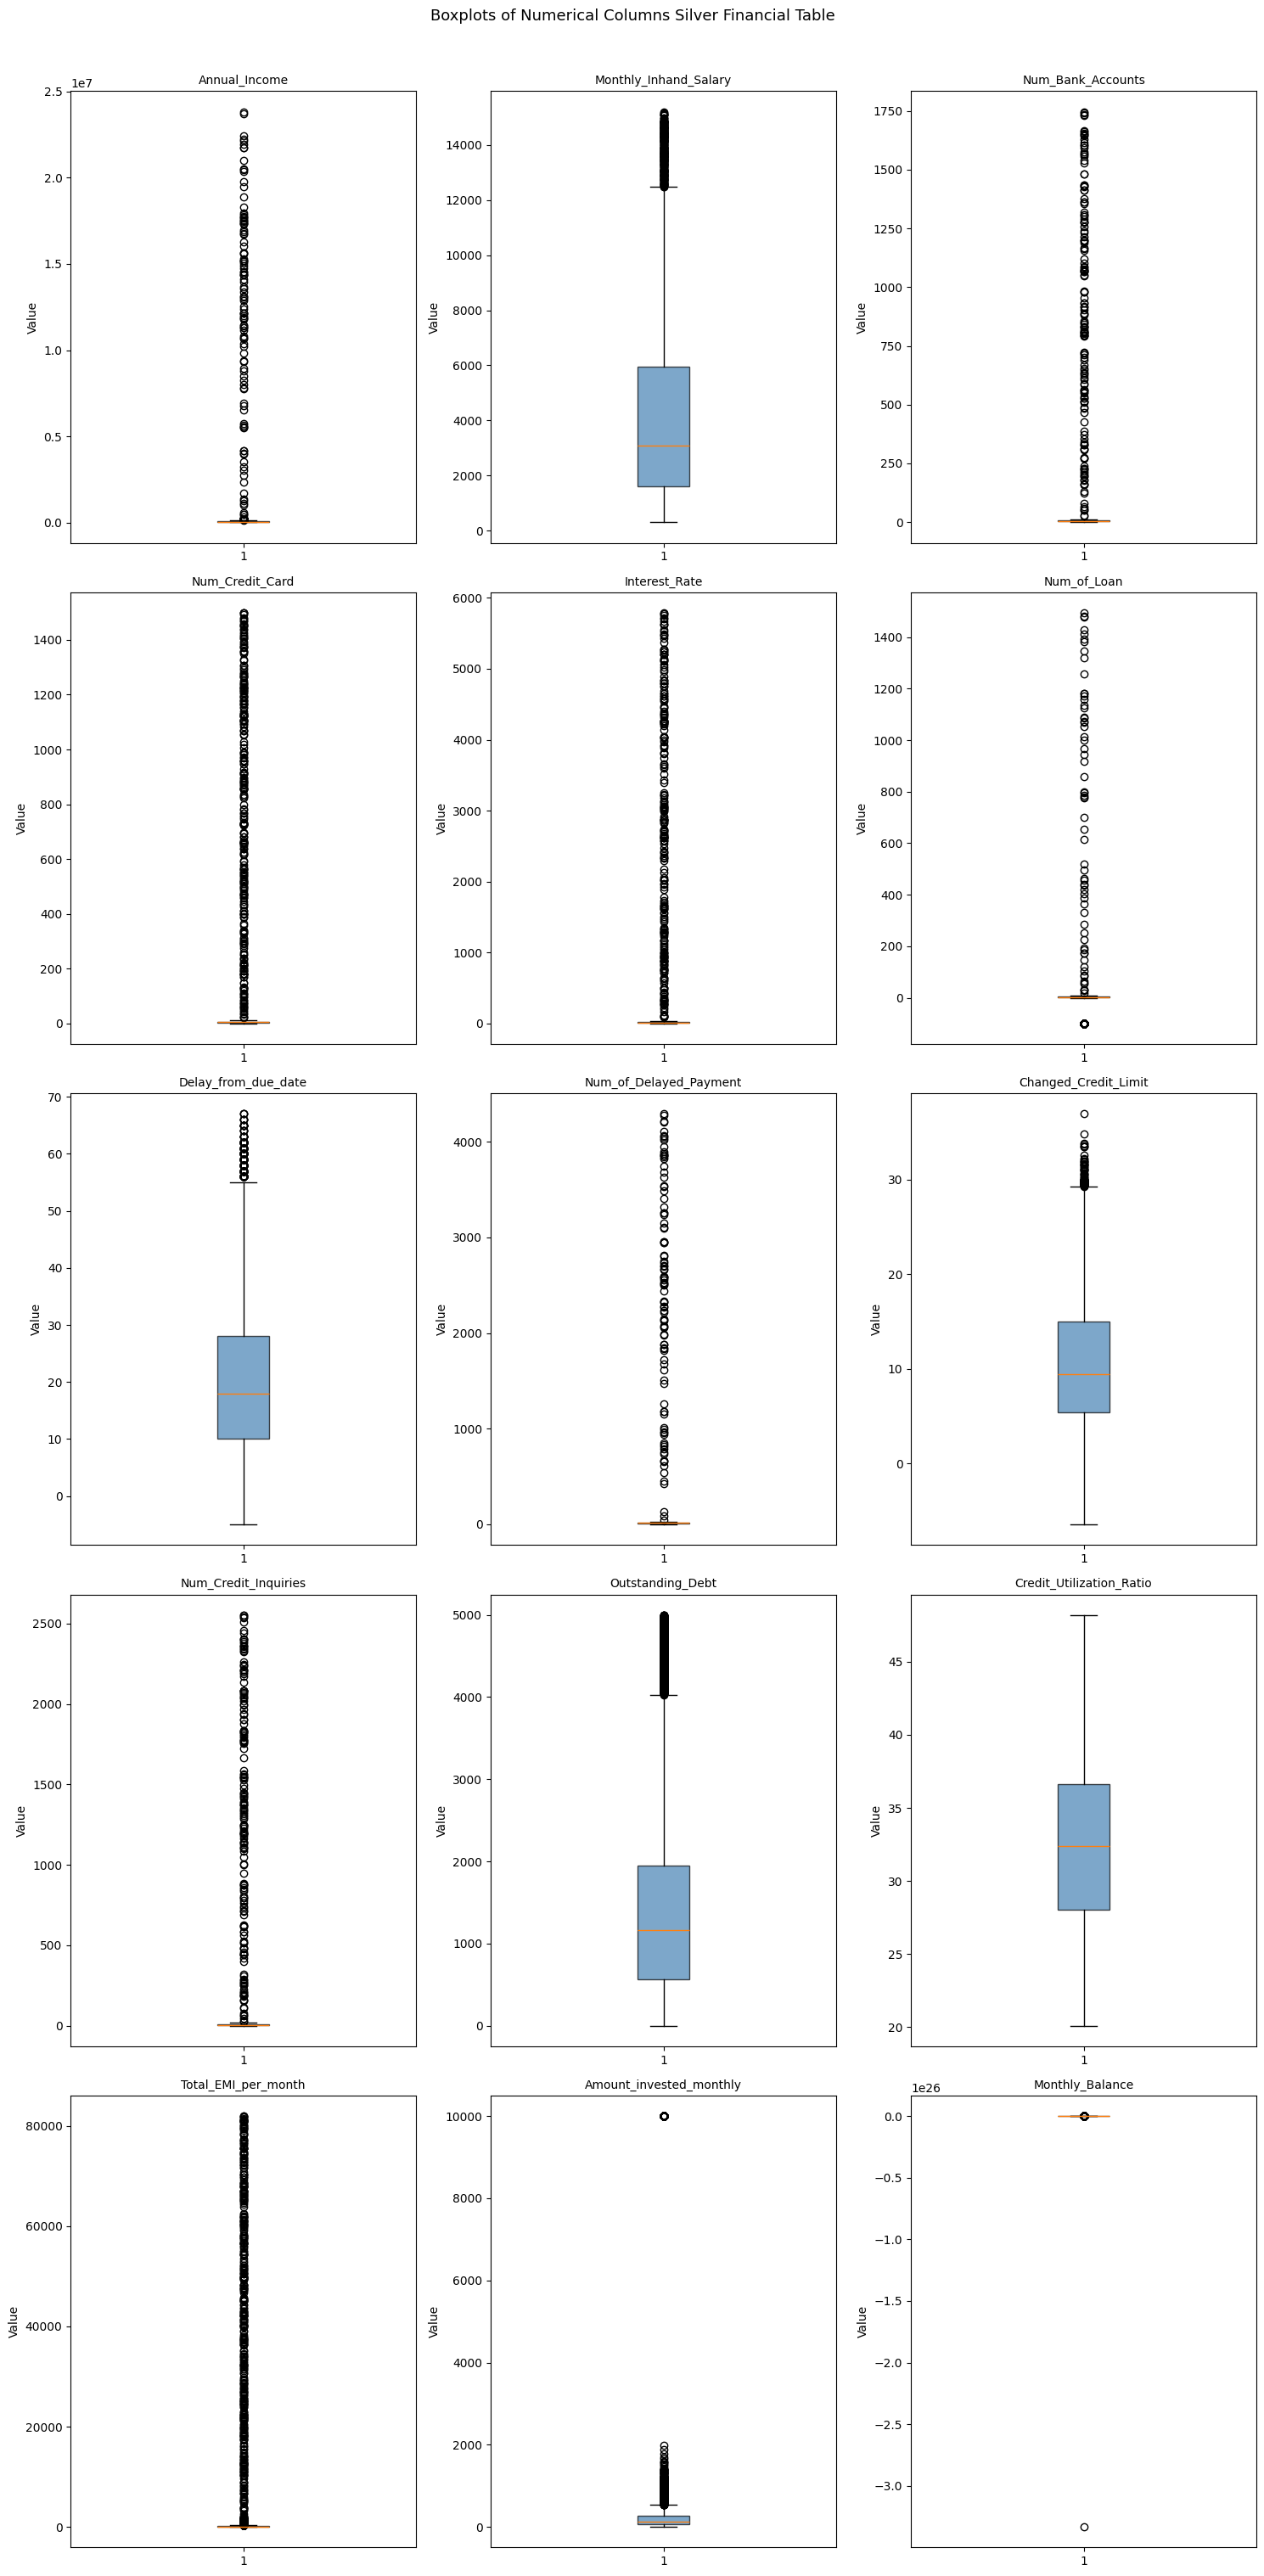

In [148]:
# Identify numerical columns from schema
from pyspark.sql.types import NumericType
num_cols = [f.name for f in fin_df.schema.fields if isinstance(f.dataType, NumericType)]
print("Numerical columns:", num_cols)

# Convert to pandas only for visualization
fin_pdf = fin_df.toPandas()

fig, axes = plt.subplots(5, 3, figsize=(15, 30))
axes = axes.flatten()

for i, col_name in enumerate(num_cols):
    axes[i].boxplot(fin_pdf[col_name].dropna(), vert=True, patch_artist=True, boxprops=dict(facecolor='steelblue', alpha=0.7))
    axes[i].set_title(col_name, fontsize=10)
    axes[i].set_ylabel('Value')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots of Numerical Columns Silver Financial Table', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Remove Negative Numbers

In [149]:
# Remove rows where any numerical column contains a negative value
print(f"Rows before negative removal: {fin_df.count()}")

filtered_df = fin_df
for col_name in num_cols:
    before = filtered_df.count()
    filtered_df = filtered_df.filter(col(col_name) >= 0)
    removed = before - filtered_df.count()
    if removed > 0:
        print(f"{col_name}: removed {removed} rows with negative values")

print(f"Rows after negative removal: {filtered_df.count()}")
filtered_df.show(5)

Rows before negative removal: 11974


Num_Bank_Accounts: removed 4 rows with negative values


Num_of_Loan: removed 486 rows with negative values


Delay_from_due_date: removed 78 rows with negative values


Num_of_Delayed_Payment: removed 81 rows with negative values


Changed_Credit_Limit: removed 419 rows with negative values


Monthly_Balance: removed 1 rows with negative values


Rows after negative removal: 10905
+-----------+-------------+---------------------+-----------------+---------------+-------------+-----------+--------------------+-------------------+----------------------+--------------------+--------------------+----------+----------------+------------------------+--------------------+---------------------+-------------------+-----------------------+--------------------+---------------+-------------+
|Customer_ID|Annual_Income|Monthly_Inhand_Salary|Num_Bank_Accounts|Num_Credit_Card|Interest_Rate|Num_of_Loan|        Type_of_Loan|Delay_from_due_date|Num_of_Delayed_Payment|Changed_Credit_Limit|Num_Credit_Inquiries|Credit_Mix|Outstanding_Debt|Credit_Utilization_Ratio|  Credit_History_Age|Payment_of_Min_Amount|Total_EMI_per_month|Amount_invested_monthly|   Payment_Behaviour|Monthly_Balance|snapshot_date|
+-----------+-------------+---------------------+-----------------+---------------+-------------+-----------+--------------------+-------------------+-

## Remove Outliers

In [150]:
# Specify which columns to apply outlier removal on
cols_to_clip = [
    "Annual_Income",
    "Monthly_Inhand_Salary",
    "Num_Bank_Accounts",
    "Num_Credit_Card",
    "Interest_Rate",
    "Num_of_Loan",
    "Num_of_Delayed_Payment",
    "Num_Credit_Inquiries",
    "Outstanding_Debt",
    "Total_EMI_per_month",
    "Amount_invested_monthly",
    "Monthly_Balance",
]

print(f"Rows before outlier removal: {filtered_df.count()}")

for col_name in cols_to_clip:
    Q1, Q3 = filtered_df.approxQuantile(col_name, [0.25, 0.75], 0.0)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    before = filtered_df.count()
    filtered_df = filtered_df.filter((col(col_name) >= lower) & (col(col_name) <= upper))
    removed = before - filtered_df.count()
    print(f"  {col_name}: whiskers [{lower:.2f}, {upper:.2f}] removed {removed} rows")

print(f"Rows after outlier removal: {filtered_df.count()}")

Rows before outlier removal: 10905
  Annual_Income: whiskers [-60412.42, 152109.95] removed 292 rows


  Monthly_Inhand_Salary: whiskers [-4650.10, 12021.43] removed 87 rows


  Num_Bank_Accounts: whiskers [-2.00, 14.00] removed 146 rows


  Num_Credit_Card: whiskers [-0.50, 11.50] removed 256 rows


  Interest_Rate: whiskers [-11.50, 40.50] removed 219 rows


...

  Outstanding_Debt: whiskers [-1596.13, 4208.78] removed 439 rows


  Total_EMI_per_month: whiskers [-168.84, 362.60] removed 693 rows


  Amount_invested_monthly: whiskers [-187.11, 501.78] removed 901 rows


  Monthly_Balance: whiskers [-2.21, 735.56] removed 570 rows


Rows after outlier removal: 7017


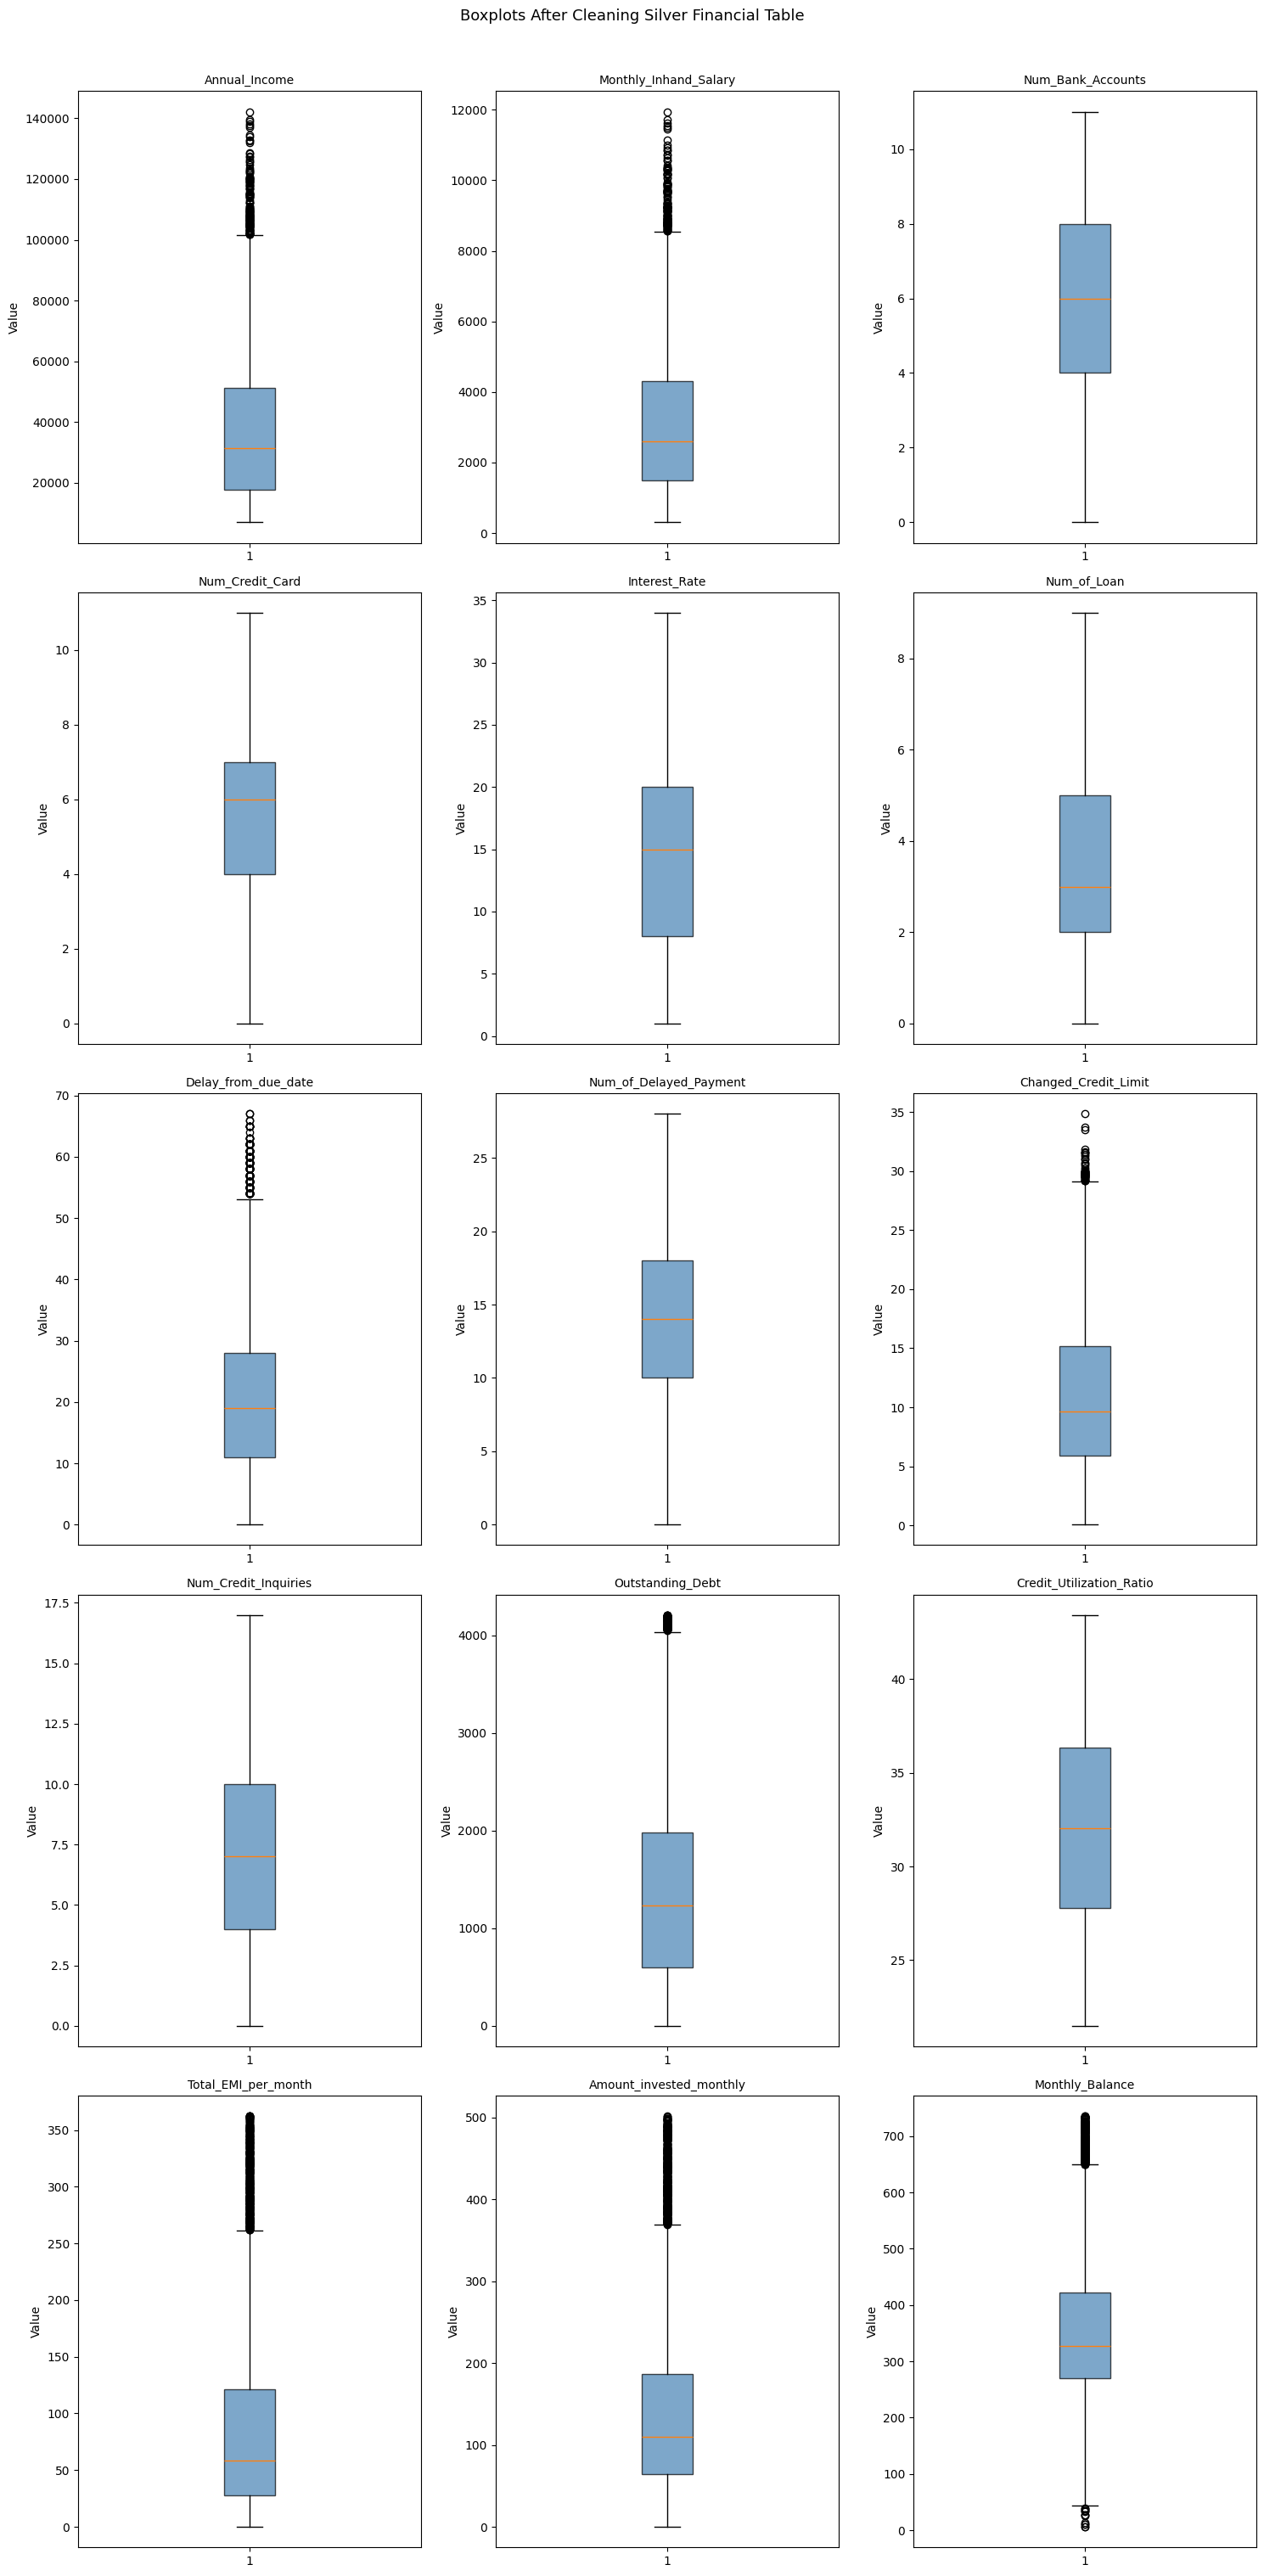

In [151]:
# Boxplot after cleaning to verify outlier and negative removal
filtered_pdf = filtered_df.toPandas()
num_cols_clean = filtered_pdf.select_dtypes(include="number").columns.tolist()

fig, axes = plt.subplots(5, 3, figsize=(15, 30))
axes = axes.flatten()

for i, col_name in enumerate(num_cols_clean):
    axes[i].boxplot(filtered_pdf[col_name].dropna(), vert=True, patch_artist=True, boxprops=dict(facecolor="steelblue", alpha=0.7))
    axes[i].set_title(col_name, fontsize=10)
    axes[i].set_ylabel("Value")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Boxplots After Cleaning Silver Financial Table", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Check for NULLs

In [152]:
# Check for NULLs and empty strings across all columns
null_counts = filtered_df.select([
    F.sum((F.col(c).isNull() | (F.col(c).cast("string") == "")).cast("int")).alias(c)
    for c in filtered_df.columns
]).toPandas().T.rename(columns={0: "null_count"})

null_counts["null_pct"] = (null_counts["null_count"] / filtered_df.count() * 100).round(2)
print(null_counts.to_string())

                          null_count  null_pct
Customer_ID                        0      0.00
Annual_Income                      0      0.00
Monthly_Inhand_Salary              0      0.00
Num_Bank_Accounts                  0      0.00
Num_Credit_Card                    0      0.00
Interest_Rate                      0      0.00
Num_of_Loan                        0      0.00
Type_of_Loan                     676      9.63
Delay_from_due_date                0      0.00
Num_of_Delayed_Payment             0      0.00
Changed_Credit_Limit               0      0.00
Num_Credit_Inquiries               0      0.00
Credit_Mix                      1468     20.92
Outstanding_Debt                   0      0.00
Credit_Utilization_Ratio           0      0.00
Credit_History_Age                 0      0.00
Payment_of_Min_Amount              0      0.00
Total_EMI_per_month                0      0.00
Amount_invested_monthly            0      0.00
Payment_Behaviour                  0      0.00
Monthly_Balan

## Remove NULLs and empty rows

In [153]:
print(f"Rows before dropping: {filtered_df.count()}")
filtered_df = filtered_df.dropna()
print(f"Rows after dropping nulls: {filtered_df.count()}")

filtered_df = filtered_df.filter(col("Payment_of_Min_Amount") != "NM")
print(f"Rows after dropping NM in Payment_of_Min_Amount: {filtered_df.count()}")

filtered_df = filtered_df.filter(col("Payment_Behaviour") != "!@9#%8")
print(f"Rows after dropping !@9#%8 in Payment_Behaviour: {filtered_df.count()}")

Rows before dropping: 7017


Rows after dropping nulls: 5007
Rows after dropping NM in Payment_of_Min_Amount: 4447


Rows after dropping !@9#%8 in Payment_Behaviour: 4097


## Remove Duplicate Values in Type_of_Loan

In [154]:
import re
from pyspark.sql.functions import udf

def dedup_loan_types(loan_str):
    if loan_str is None:
        return None
    # Strip leading "and " from each part
    parts = [re.sub(r'^and\s+', '', p.strip()) for p in loan_str.split(",")]
    seen = []
    for p in parts:
        if p and p not in seen:
            seen.append(p)
    return ", ".join(seen)

dedup_udf = udf(dedup_loan_types, StringType())
filtered_df = filtered_df.withColumn("Type_of_Loan", dedup_udf(col("Type_of_Loan")))

In [155]:
filtered_df.toPandas().to_csv("fin_df_check.csv", index=False)

## Save Cleaned Financial Data to Silver

In [156]:
# Save cleaned financial data as a single parquet (overwrites the initial silver file)
filtered_df.cache()
filtered_df.count()

filtered_df.write.mode("overwrite").parquet(fin_silver_path)
print(f"saved to: {fin_silver_path} ({filtered_df.count()} rows)")

filtered_df.unpersist()

saved to: datamart/silver/financial/silver_financial.parquet (4097 rows)


DataFrame[Customer_ID: string, Annual_Income: float, Monthly_Inhand_Salary: float, Num_Bank_Accounts: int, Num_Credit_Card: int, Interest_Rate: int, Num_of_Loan: int, Type_of_Loan: string, Delay_from_due_date: int, Num_of_Delayed_Payment: int, Changed_Credit_Limit: float, Num_Credit_Inquiries: int, Credit_Mix: string, Outstanding_Debt: float, Credit_Utilization_Ratio: float, Credit_History_Age: string, Payment_of_Min_Amount: string, Total_EMI_per_month: float, Amount_invested_monthly: float, Payment_Behaviour: string, Monthly_Balance: float, snapshot_date: date]

## Build Silver Table for Attributes

In [157]:
# create silver datalake for attributes
silver_attr_directory = "datamart/silver/attributes/"

if not os.path.exists(silver_attr_directory):
    os.makedirs(silver_attr_directory)

In [158]:
# Load all bronze attributes CSVs at once and process
all_attr_files = glob.glob(os.path.join(bronze_attr_directory, '*.csv'))
df = spark.read.csv(all_attr_files, header=True, inferSchema=True)
print(f"loaded {len(all_attr_files)} files, total row count: {df.count()}")

column_type_map = {
    "Customer_ID": StringType(),
    "Name": StringType(),
    "Age": IntegerType(),
    "SSN": StringType(),
    "Occupation": StringType(),
    "snapshot_date": DateType()
}

numeric_cols = [(c, t) for c, t in column_type_map.items() if isinstance(t, (FloatType, IntegerType))]
for column, col_type in numeric_cols:
    df = df.withColumn(column, F.regexp_replace(col(column).cast(StringType()), "_", ""))

for column, new_type in column_type_map.items():
    df = df.withColumn(column, col(column).cast(new_type))

attr_silver_path = silver_attr_directory + "silver_attributes.parquet"
df.write.mode("overwrite").parquet(attr_silver_path)
print(f"saved to: {attr_silver_path} ({df.count()} rows)")

loaded 24 files, total row count: 11974


saved to: datamart/silver/attributes/silver_attributes.parquet (11974 rows)


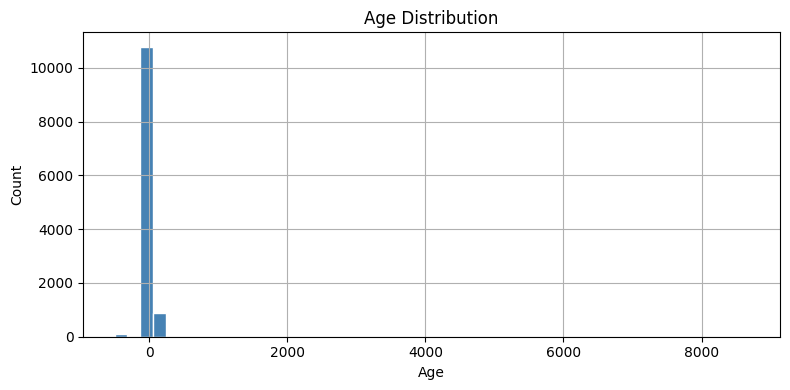

In [159]:
age_pdf = df.toPandas()

plt.figure(figsize=(8, 4))
plt.hist(age_pdf["Age"], bins=50, color="steelblue", edgecolor="white")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.grid(True)
plt.tight_layout()
plt.show()

In [160]:
df.toPandas()

,Customer_ID,Name,Age,SSN,Occupation,snapshot_date
0,CUS_0x10ac,Zhouy,29,780-50-4730,Developer,2024-08-01
1,CUS_0x10c5,Moony,24,041-74-6785,_______,2024-08-01
2,CUS_0x1145,Blenkinsopr,24,426-31-9194,Teacher,2024-08-01
3,CUS_0x11ac,Liana B.v,26,835-92-7751,Journalist,2024-08-01
4,CUS_0x122c,Papadimasf,48,883-73-9594,Entrepreneur,2024-08-01
...,...,...,...,...,...,...
11969,CUS_0xdf6,Euan Rochaa,55,155-73-3803,Mechanic,2023-09-01
11970,CUS_0xe23,Soyoung Kimg,39,825-49-2383,Musician,2023-09-01
11971,CUS_0xe4e,Mirwaisd,22,952-71-5963,Scientist,2023-09-01
11972,CUS_0xedd,Lauren Tarao,-500,888-82-5609,Engineer,2023-09-01


## Remove Invalid rows for Age, SSN, and Occupation

In [161]:
print(f"Rows before age filter: {df.count()}")
filtered_df = df.filter((col("Age") >= 0) & (col("Age") <= 100))
print(f"Rows after age filter: {df.count()}")

print(f"Rows before SSN filter: {filtered_df.count()}")
filtered_df = filtered_df.filter(col("SSN") != "#F%$D@*&8")
print(f"Rows after dropping #F%$D@*&8 in SSN: {filtered_df.count()}")

print(f"Rows before Occupation filter: {filtered_df.count()}")
filtered_df = filtered_df.filter(col("Occupation") != "_______")
print(f"Rows after dropping _______ in Occupation: {filtered_df.count()}")

Rows before age filter: 11974
Rows after age filter: 11974
Rows before SSN filter: 11670
Rows after dropping #F%$D@*&8 in SSN: 11011
Rows before Occupation filter: 11011
Rows after dropping _______ in Occupation: 10232


## Clean Name Column

In [163]:
# Extract name between quotes; leaves names without quotes unchanged
filtered_df = filtered_df.withColumn("Name", F.regexp_extract(col("Name"), r'^"*([^"]+)', 1))

In [164]:
filtered_df.toPandas().to_csv("attr_df_check.csv", index=False)